In [1]:
pip install --upgrade pip && pip install "numpy==1.26.4" snntorch h5py scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [7]:
import os
import numpy as np
from glob import glob
from tqdm import tqdm

TRAIN_DIR = "TrainData"
TEST_DIR = "TestData"
CACHE_PATH = "cached_data/TimeSeries_seq.npz"
SEQ_LEN = 3000

os.makedirs(os.path.dirname(CACHE_PATH), exist_ok=True)

def build_labels(tag_times, tag_values, seq_len=SEQ_LEN):
    labels = np.zeros(seq_len, dtype=np.int64)
    for t, v in zip(tag_times, tag_values):
        if 0 <= t < seq_len and v in [1, 2]:
            labels[t] = v
    return labels

def load_folder(folder):
    X_list, y_list = [], []
    files = sorted(glob(os.path.join(folder, "*.npz")))
    print(f"Found {len(files)} files in {folder}")
    for fpath in tqdm(files, desc=f"Loading {folder}"):
        data = np.load(fpath)
        wf = data["wf_i"]             # (N,3000)
        times = data["tag_times"]     # (N,300)
        values = data["tag_values"]   # (N,300)

        for i in range(wf.shape[0]):
            X_list.append(wf[i][:, None])  # (3000,1)
            y_list.append(build_labels(times[i], values[i]))  # (3000,)
    return np.stack(X_list), np.stack(y_list)

print("Processing TrainData...")
X_train, y_train = load_folder(TRAIN_DIR)

print("Processing TestData...")
X_test, y_test = load_folder(TEST_DIR)

print("✅ Final shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

np.savez_compressed(
    CACHE_PATH,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

print(f"✅ Saved sequence dataset to {CACHE_PATH}")


Processing TrainData...
Found 5 files in TrainData


Loading TrainData: 100%|██████████| 5/5 [28:10<00:00, 338.19s/it]


Processing TestData...
Found 5 files in TestData


Loading TestData: 100%|██████████| 5/5 [27:22<00:00, 328.43s/it]


✅ Final shapes:
X_train: (500000, 3000, 1) y_train: (500000, 3000)
X_test: (500000, 3000, 1) y_test: (500000, 3000)
✅ Saved sequence dataset to cached_data/TimeSeries_seq.npz


In [3]:
import numpy as np

# Load one file to inspect
data = np.load("TrainData/batch_0.npz")

print("Keys in file:", list(data.keys()))
for k in data.keys():
    print(f"{k}: shape {data[k].shape}, dtype {data[k].dtype}")


Keys in file: ['wf_i', 'mom', 'tag_times', 'tag_values']
wf_i: shape (100000, 3000), dtype float32
mom: shape (100000,), dtype float32
tag_times: shape (100000, 300), dtype int32
tag_values: shape (100000, 300), dtype int32


In [4]:
import numpy as np

# Load one file to inspect
data = np.load("TestData/batch_0.npz")

print("Keys in file:", list(data.keys()))
for k in data.keys():
    print(f"{k}: shape {data[k].shape}, dtype {data[k].dtype}")


Keys in file: ['wf_i', 'mom', 'tag_times', 'tag_values']
wf_i: shape (100000, 3000), dtype float32
mom: shape (100000,), dtype float32
tag_times: shape (100000, 300), dtype int32
tag_values: shape (100000, 300), dtype int32


In [5]:
print(data['wf_i'][0])
print(data['mom'][0])
print(data['tag_times'][0])
print(data['tag_values'][0])

[ 0.00515131 -0.01233609 -0.0100005  ...  0.11087434  0.10352787
  0.08794087]
19.994886
[ 139  140  173  175  184  290  296  300  303  361  371  600  652  691
  727  746  883  938  967  978 1026 1072 1088 1291 1334 1377 1392 1905
 2175 2256 2319 2983    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm

# === CONFIG ===
CACHE_PATH = "cached_data/TimeSeries_seq.npz"
CHECKPOINT_DIR = "checkpoints_snn_seq"
RESULT_PATH = "results/snn_seq.npz"
BATCH_SIZE = 32
NUM_EPOCHS = 30
PATIENCE = 5
NUM_TIMESTEPS = 5
NUM_CLASSES = 3   # 0=background, 1=primary, 2=secondary

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# === Load dataset ===
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)
# Expect: X_train (N,3000,1), y_train (N,3000)

# === Normalize waveforms ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# === Torch tensors ===
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# === Model ===
class SeqSNN(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)   # [B,1,3000]

        mem1, mem2 = self.lif1.init_leaky(), self.lif2.init_leaky()
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)   # [B,64,3000]

            spk2 = spk2.permute(0, 2, 1)         # [B,3000,64]
            out  = self.fc(spk2)                 # [B,3000,3]
            spk_out.append(out)

        return torch.stack(spk_out, dim=2)       # [B,3000,Tsteps,3]

# === Training setup ===
device = torch.device("cuda" if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu")
print("Using device:", device)

model = SeqSNN(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_loss, early_counter = float("inf"), 0
start_epoch = 0

# === Resume if checkpoint exists ===
checkpoint_files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("epoch_")])
if checkpoint_files:
    latest_ckpt = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])
    print(f"🔄 Resuming from {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_loss = checkpoint.get("best_loss", float("inf"))

# === Training loop ===
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack = model(xb)
        out = out_stack.mean(dim=2)              # [B,3000,3]

        loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1} Train Loss {train_loss:.4f}")

    # === Validation ===
    val_loss, correct, total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb).mean(dim=2)          # [B,3000,3]
            loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
            val_loss += loss.item() * xb.size(0)

            preds = out.argmax(dim=-1)           # [B,3000]
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total
    print(f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    # === Save checkpoint ===
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt")
    torch.save({
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "best_loss": best_loss
    }, ckpt_path)

    # === Save best model ===
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("⏹️ Early stopping.")
            break

# === Evaluation ===
print("🔎 Evaluating best model...")
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt")))
model.eval()
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb).mean(dim=2)  # [B,3000,3]
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        y_true_all.append(yb.numpy())
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0).ravel()
y_pred_all = np.concatenate(y_pred_all, axis=0)  # [N*3000,3]

# === ROC / AUC ===
plt.figure(figsize=(6,6))
for cls, label in [(1,"Primary"),(2,"Secondary")]:
    fpr,tpr,_=roc_curve((y_true_all==cls).astype(int), y_pred_all[:,cls])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{label} AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC per Class (SNN)")
plt.legend(); plt.grid(True); plt.show()


Loading dataset...



KeyboardInterrupt



Loading dataset...
✅ Shapes: (500000, 3000, 1) (500000, 3000) (500000, 3000, 1) (500000, 3000)
Using device: cuda
🔄 Resuming from checkpoints_snn_seq/epoch_030.pt


/tmp/ipykernel_108/734489548.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(latest_ckpt)


🔎 Evaluating best model...


/tmp/ipykernel_108/734489548.py:161: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt")))


Shapes after evaluation: (1500000000,) (1500000000, 3)
AUC Primary: 0.9945
AUC Secondary: 0.9952


/tmp/ipykernel_108/734489548.py:193: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("results/roc_curve.png")


✅ ROC curve saved to results/roc_curve.png


OSError: [Errno 28] No space left on device

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


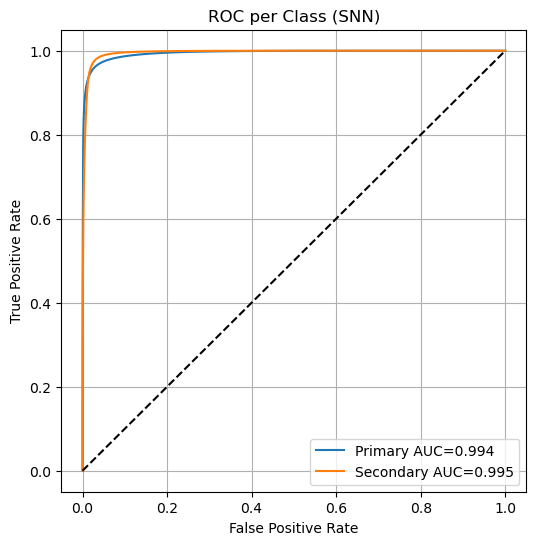

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm

# === CONFIG ===
CACHE_PATH = "cached_data/TimeSeries_seq.npz"
CHECKPOINT_DIR = "checkpoints_snn_seq"
RESULT_PATH = "results/snn_seq.npz"
BATCH_SIZE = 32
NUM_EPOCHS = 30
PATIENCE = 5
NUM_TIMESTEPS = 5
NUM_CLASSES = 3   # 0=background, 1=primary, 2=secondary

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# === Load dataset ===
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# === Normalize waveforms ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# === Torch tensors ===
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# === Model ===
class SeqSNN(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)   # [B,1,3000]

        mem1, mem2 = self.lif1.init_leaky(), self.lif2.init_leaky()
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)   # [B,64,3000]

            spk2 = spk2.permute(0, 2, 1)         # [B,3000,64]
            out  = self.fc(spk2)                 # [B,3000,3]
            spk_out.append(out)

        return torch.stack(spk_out, dim=2)       # [B,3000,Tsteps,3]

# === Training setup ===
device = torch.device("cuda" if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu")
print("Using device:", device)
model = SeqSNN(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_loss, early_counter = float("inf"), 0
start_epoch = 0

# === Resume if checkpoint exists ===
checkpoint_files = sorted([f for f in os.listdir(CHECKPOINT_DIR) if f.startswith("epoch_")])
if checkpoint_files:
    latest_ckpt = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])
    print(f"🔄 Resuming from {latest_ckpt}")
    checkpoint = torch.load(latest_ckpt)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]
    best_loss = checkpoint.get("best_loss", float("inf"))

# === Training loop ===
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack = model(xb)
        out = out_stack.mean(dim=2)              # [B,3000,3]

        loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1} Train Loss {train_loss:.4f}")

    # === Validation ===
    val_loss, correct, total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb).mean(dim=2)          # [B,3000,3]
            loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
            val_loss += loss.item() * xb.size(0)

            preds = out.argmax(dim=-1)           # [B,3000]
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total
    print(f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    # === Save checkpoint ===
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch+1:03d}.pt")
    torch.save({
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "best_loss": best_loss
    }, ckpt_path)

    # === Save best model ===
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("⏹️ Early stopping.")
            break

# === Final Evaluation on test set ===
print("🔎 Evaluating best model...")
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt")))
model.eval()
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb).mean(dim=2)  # [B,3000,3]
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        y_true_all.append(yb.numpy())
        y_pred_all.append(probs)

# Flatten properly: [N*3000] vs [N*3000,3]
y_true_all = np.concatenate(y_true_all, axis=0).ravel()
y_pred_all = np.concatenate(y_pred_all, axis=0).reshape(-1, 3)

print("Shapes after evaluation:", y_true_all.shape, y_pred_all.shape)

# === ROC / AUC ===
plt.figure(figsize=(6,6))
for cls, label in [(1,"Primary"), (2,"Secondary")]:
    fpr, tpr, _ = roc_curve((y_true_all==cls).astype(int), y_pred_all[:,cls])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} AUC={roc_auc:.3f}")
    print(f"AUC {label}: {roc_auc:.4f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC per Class (SNN)")
plt.legend(); plt.grid(True)

# Save instead of blocking show
plt.savefig("results/roc_curve.png")
print("✅ ROC curve saved to results/roc_curve.png")

# === SAVE RESULTS ===
np.savez(RESULT_PATH,
         probs=y_pred_all,
         y_true=y_true_all)
print(f"✅ Saved results to {RESULT_PATH}")


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from tqdm import tqdm

# === CONFIG ===
CACHE_PATH = "cached_data/TimeSeries_seq.npz"
CHECKPOINT_DIR = "checkpoints_snn_seq_v2"   # new checkpoint folder
RESULT_PATH = "results/snn_seq_seqlevel.npz" # new result file
BATCH_SIZE = 32
NUM_EPOCHS = 30
PATIENCE = 5
NUM_TIMESTEPS = 5
NUM_CLASSES = 3   # 0=background, 1=primary, 2=secondary

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# === Load dataset ===
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# === Normalize waveforms ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# === Torch tensors ===
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# === Model ===
class SeqSNN(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)   # [B,1,3000]

        mem1, mem2 = self.lif1.init_leaky(), self.lif2.init_leaky()
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)   # [B,64,3000]

            spk2 = spk2.permute(0, 2, 1)         # [B,3000,64]
            out  = self.fc(spk2)                 # [B,3000,3]
            spk_out.append(out)

        return torch.stack(spk_out, dim=2)       # [B,3000,Tsteps,3]

# === Training setup ===
device = torch.device("cuda" if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu")
print("Using device:", device)

model = SeqSNN(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_loss, early_counter = float("inf"), 0
start_epoch = 0

# === Training loop ===
for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        xb, yb = xb.to(device), yb.to(device)
        out_stack = model(xb)
        out = out_stack.mean(dim=2)              # [B,3000,3]

        loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1} Train Loss {train_loss:.4f}")

    # === Validation ===
    val_loss, correct, total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb).mean(dim=2)          # [B,3000,3]
            loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
            val_loss += loss.item() * xb.size(0)

            preds = out.argmax(dim=-1)           # [B,3000]
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total
    print(f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    # === Save best model ===
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        if early_counter >= PATIENCE:
            print("⏹️ Early stopping.")
            break

# === Evaluation ===
print("🔎 Evaluating best model...")
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt")))
model.eval()
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb).mean(dim=2)  # [B,3000,3]
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        y_true_all.append(yb.numpy())
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0).ravel()          # [N*3000]
y_pred_all = np.concatenate(y_pred_all, axis=0).reshape(-1, 3)   # [N*3000,3]

print("Shapes after evaluation:", y_true_all.shape, y_pred_all.shape)

# --- Timestep-level AUC (old way) ---
plt.figure(figsize=(6,6))
for cls, label in [(1,"Primary"),(2,"Secondary")]:
    fpr,tpr,_=roc_curve((y_true_all==cls).astype(int), y_pred_all[:,cls])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{label} Step AUC={roc_auc:.3f}")
    print(f"Timestep-level AUC {label}: {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC per Class (Timestep-level)")
plt.legend(); plt.grid(True)
plt.savefig("results/roc_curve_timestep.png")
print("✅ Saved ROC curve (timestep-level)")

# --- Sequence-level AUC (new way) ---
n_samples = len(y_true_all)//3000
y_true_seq = y_true_all.reshape(n_samples, 3000)[:,0]
y_pred_seq = y_pred_all.reshape(n_samples, 3000, 3).mean(1)

plt.figure(figsize=(6,6))
for cls, label in [(1,"Primary"),(2,"Secondary")]:
    fpr,tpr,_=roc_curve((y_true_seq==cls).astype(int), y_pred_seq[:,cls])
    roc_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{label} Seq AUC={roc_auc:.3f}")
    print(f"Sequence-level AUC {label}: {roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC per Class (Sequence-level)")
plt.legend(); plt.grid(True)
plt.savefig("results/roc_curve_sequence.png")
print("✅ Saved ROC curve (sequence-level)")

# === SAVE RESULTS (compact) ===
np.savez(RESULT_PATH, probs_seq=y_pred_seq, y_true_seq=y_true_seq)
print(f"✅ Saved results to {RESULT_PATH}")


Loading dataset...
✅ Shapes: (500000, 3000, 1) (500000, 3000) (500000, 3000, 1) (500000, 3000)
Using device: cuda


Epoch 1 Training: 100%|██████████| 15625/15625 [08:40<00:00, 30.02it/s]


Epoch 1 Train Loss 0.0265
Val Loss 0.0174 | Val Acc 0.9948
✅ New best model saved


Epoch 2 Training: 100%|██████████| 15625/15625 [08:40<00:00, 30.01it/s]


Epoch 2 Train Loss 0.0168
Val Loss 0.0163 | Val Acc 0.9951
✅ New best model saved


...

Epoch 4 Training: 100%|██████████| 15625/15625 [08:33<00:00, 30.40it/s]


Epoch 4 Train Loss 0.0159
Val Loss 0.0157 | Val Acc 0.9953
✅ New best model saved


Epoch 5 Training: 100%|██████████| 15625/15625 [08:32<00:00, 30.47it/s]


Epoch 5 Train Loss 0.0157
Val Loss 0.0156 | Val Acc 0.9953
✅ New best model saved


Epoch 6 Training:   5%|▍         | 735/15625 [00:24<08:07, 30.53it/s]

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# === CONFIG ===
CACHE_PATH = "cached_data/TimeSeries_seq.npz"
CHECKPOINT_DIR = "checkpoints_snn_seq"
RESULT_PATH = "results/snn_seq_results.npz"
BATCH_SIZE = 32
NUM_TIMESTEPS = 5
NUM_CLASSES = 3

os.makedirs("results", exist_ok=True)

# === Load dataset ===
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_test, y_test = data["X_test"], data["y_test"]

# Normalize (same scaler as training, approx)
scaler = StandardScaler()
X_test = scaler.fit_transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Torch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                         batch_size=BATCH_SIZE, shuffle=False)

# === Define Model ===
class SeqSNN(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=3):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.fc    = nn.Linear(64, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)   # [B,1,3000]
        mem1, mem2 = self.lif1.init_leaky(), self.lif2.init_leaky()
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)   # [B,64,3000]
            spk2 = spk2.permute(0, 2, 1)         # [B,3000,64]
            out  = self.fc(spk2)                 # [B,3000,3]
            spk_out.append(out)
        return torch.stack(spk_out, dim=2)       # [B,3000,Tsteps,3]

# === Load checkpoint ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SeqSNN(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=device))
model.eval()
print("✅ Loaded best checkpoint")

# === Evaluation ===
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb).mean(dim=2)  # [B,3000,3]
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        y_true_all.append(yb.numpy())
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0).ravel()
y_pred_all = np.concatenate(y_pred_all, axis=0).reshape(-1, NUM_CLASSES)

print("Shapes:", y_true_all.shape, y_pred_all.shape)

# === Save results properly ===
np.savez_compressed(RESULT_PATH,
    probs=y_pred_all.astype(np.float32),
    y_true=y_true_all.astype(np.int16)
)
print(f"✅ Saved results to {RESULT_PATH}")

# === Purity & Efficiency calculation ===
def purity_efficiency(y_true, y_scores, cls=1, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 200)
    purity, efficiency = [], []
    mask_true = (y_true == cls).astype(int)
    for thr in thresholds:
        preds = (y_scores[:, cls] >= thr).astype(int)
        TP = np.sum((preds == 1) & (mask_true == 1))
        FP = np.sum((preds == 1) & (mask_true == 0))
        FN = np.sum((preds == 0) & (mask_true == 1))
        p = TP / (TP + FP) if (TP+FP) > 0 else 0
        e = TP / (TP + FN) if (TP+FN) > 0 else 0
        purity.append(p); efficiency.append(e)
    return thresholds, np.array(purity), np.array(efficiency)

# === Plot curves for Primary and Secondary ===
plt.figure(figsize=(12, 5))
for i, (cls, label) in enumerate([(1, "Primary"), (2, "Secondary")], 1):
    thr, pur, eff = purity_efficiency(y_true_all, y_pred_all, cls=cls)
    # Find threshold where purity ~0.8986 (like paper)
    target_purity = 0.8986
    idx = np.argmin(np.abs(pur - target_purity))
    opt_thr, opt_p, opt_e = thr[idx], pur[idx], eff[idx]

    plt.subplot(1, 2, i)
    plt.plot(thr, pur, label="Purity")
    plt.plot(thr, eff, "--", label="Efficiency")
    plt.axvline(opt_thr, color="r", ls="--", label=f"Thr={opt_thr:.3f}")
    plt.title(f"SNN – {label}")
    plt.xlabel("Threshold"); plt.ylabel("Value of Metric")
    plt.legend(); plt.grid(True)

    print(f"{label} → Purity={opt_p:.4f}, Efficiency={opt_e:.4f}, Thr={opt_thr:.3f}")

plt.tight_layout()
plt.savefig("results/snn_purity_efficiency.png")
print("✅ Saved purity–efficiency curves to results/snn_purity_efficiency.png")


Loading dataset...


/tmp/ipykernel_119/3979785235.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=dev

✅ Loaded best checkpoint


Evaluating: 100%|██████████| 15625/15625 [04:01<00:00, 64.79it/s]


Shapes: (1500000000,) (1500000000, 3)


OSError: [Errno 28] No space left on device

New 

Loading dataset...
✅ Shapes before binarization: (100000, 3000, 1) (100000, 3000) (100000, 3000, 1) (100000, 3000)
Label distribution (train): [296511283   3488717]
Label distribution (test): [296518112   3481888]
Using device: cuda

=== Epoch 1/200 ===


Epoch 1 Training: 100%|██████████| 3125/3125 [24:43<00:00,  2.11it/s]


Train Loss 0.0240 | Train Acc 0.9926 | Val Loss 0.0137 | Val Acc 0.9957
✅ New best model saved

=== Epoch 2/200 ===


Epoch 2 Training: 100%|██████████| 3125/3125 [24:57<00:00,  2.09it/s]


Train Loss 0.0125 | Train Acc 0.9961 | Val Loss 0.0117 | Val Acc 0.9964
✅ New best model saved

=== Epoch 3/200 ===


...

Train Loss 0.0100 | Train Acc 0.9970 | Val Loss 0.0101 | Val Acc 0.9970
⚠️ No improvement (5/5)
🛑 Early stopping triggered.

🔎 Training complete. Best model saved in checkpoints_snn_seq_3000_batch0_binary_v8


/tmp/ipykernel_117/344536020.py:241: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=dev

📈 Saved training curves to results/training_curve_v8.png


Evaluating: 100%|██████████| 3125/3125 [10:53<00:00,  4.78it/s]


✅ Saved results to results/snn_seq_3000_batch0_binary_cluster_v8.npz
Best threshold = 0.430
Purity = 91.56%
Efficiency = 81.51%
Balanced score (F1) = 0.862
✅ Saved plot to results/purity_efficiency_best_v8.png


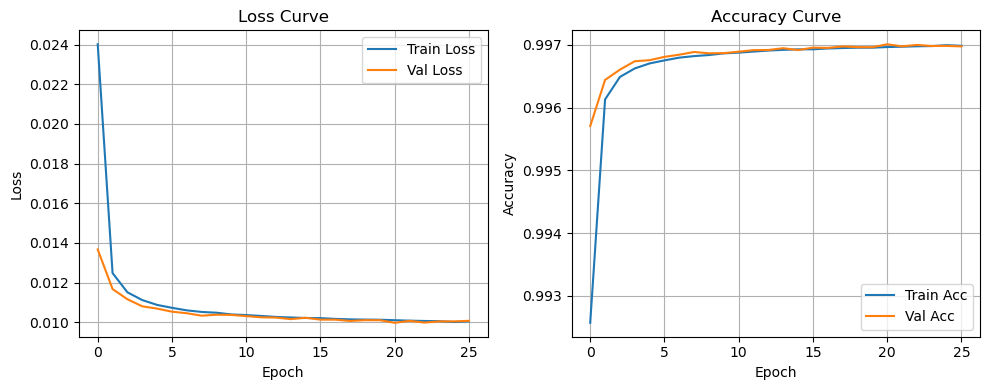

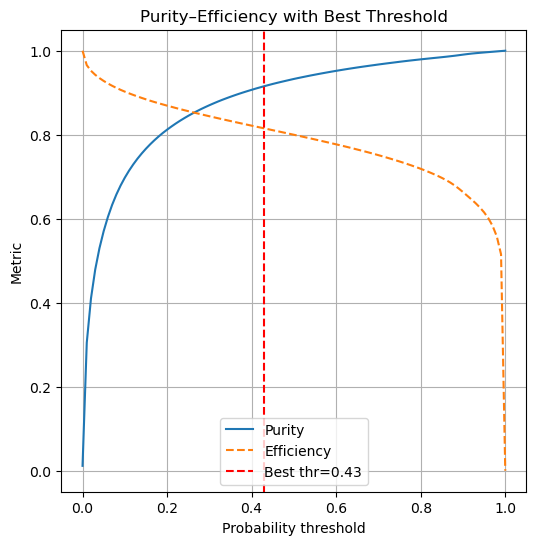

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# === CONFIG ===
# ============================================================
CACHE_PATH = "cached_data/TimeSeries_seq_3000_batch0.npz"

CHECKPOINT_DIR = "checkpoints_snn_seq_3000_batch0_binary_v8"
RESULT_PATH = "results/snn_seq_3000_batch0_binary_cluster_v8.npz"
OUT_FIG_BEST = "results/purity_efficiency_best_v8.png"
OUT_FIG_CURVE = "results/training_curve_v8.png"

BATCH_SIZE = 32
NUM_EPOCHS = 200
PATIENCE = 5          # tightened patience
NUM_TIMESTEPS = 20
NUM_CLASSES = 2

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# ============================================================
# === Load dataset ===
# ============================================================
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes before binarization:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Convert labels to binary
y_train = (y_train > 0).astype(np.int64)
y_test  = (y_test  > 0).astype(np.int64)

print("Label distribution (train):", np.bincount(y_train.reshape(-1)))
print("Label distribution (test):", np.bincount(y_test.reshape(-1)))

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# === Model (Conv→LIF→FC, twice: 64 → 128) ===
# ============================================================
class ConvSNN_Big(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(64, 64)

        # Block 2
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.fc2   = nn.Linear(128, 128)

        # Final classifier
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)

        mem1, mem2 = self.lif1.init_leaky(), self.lif2.init_leaky()
        spk_out = []
        for _ in range(num_steps):
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = spk1.permute(0, 2, 1)
            spk1 = self.fc1(spk1)

            spk1 = spk1.permute(0, 2, 1)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = spk2.permute(0, 2, 1)
            spk2 = self.fc2(spk2)

            out = self.fc_out(spk2)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)

# ============================================================
# === Training setup + Resume from checkpoint ===
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ConvSNN_Big(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_loss, early_counter = float("inf"), 0
train_curve, val_curve = [], []
train_acc_curve, val_acc_curve = [], []

start_epoch = 1
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pt")
if os.path.exists(last_ckpt):
    print(f"🔄 Resuming training from {last_ckpt}")
    checkpoint = torch.load(last_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
    start_epoch = checkpoint["epoch"]
    train_curve = checkpoint.get("train_curve", [])
    val_curve = checkpoint.get("val_curve", [])
    train_acc_curve = checkpoint.get("train_acc_curve", [])
    val_acc_curve = checkpoint.get("val_acc_curve", [])

# ============================================================
# === Training loop ===
# ============================================================
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch} Training", mininterval=1.0):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)

        loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

        preds = out.argmax(dim=-1)
        correct += (preds == yb).sum().item()
        total += yb.numel()

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # Validation
    val_loss, correct, total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
            val_loss += loss.item() * xb.size(0)

            preds = out.argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total
    print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    # Save curves
    train_curve.append(train_loss)
    val_curve.append(val_loss)
    train_acc_curve.append(train_acc)
    val_acc_curve.append(val_acc)

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        print(f"⚠️ No improvement ({early_counter}/{PATIENCE})")
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break

    # Save last checkpoint
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "train_acc_curve": train_acc_curve,
        "val_acc_curve": val_acc_curve,
    }, last_ckpt)

print("\n🔎 Training complete. Best model saved in", CHECKPOINT_DIR)

# ============================================================
# === Training curve plot ===
# ============================================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_curve, label="Train Loss")
plt.plot(val_curve, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_curve, label="Train Acc")
plt.plot(val_acc_curve, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(OUT_FIG_CURVE)
print(f"📈 Saved training curves to {OUT_FIG_CURVE}")

# ============================================================
# === Final Evaluation (with best model) ===
# ============================================================
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=device))
model.eval()
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        labels = yb.cpu().numpy()
        y_true_all.append(labels)
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

np.savez(RESULT_PATH, probs=y_pred_all, y_true=y_true_all)
print(f"✅ Saved results to {RESULT_PATH}")

# ============================================================
# === Threshold tuning ===
# ============================================================
def tune_best_threshold(y_true, y_probs, thresholds=None, ntest=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 101)
    if ntest is not None:
        y_true = y_true[:ntest]
        y_probs = y_probs[:ntest]

    yt = y_true.reshape(-1).astype(np.int8)
    pp = y_probs[:, :, 1].reshape(-1).astype(np.float32)

    best_thr, best_score = None, -1
    best_p, best_e = 0, 0
    purity, efficiency = [], []

    for thr in thresholds:
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))

        p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        e = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        purity.append(p)
        efficiency.append(e)

        score = 2 * p * e / (p + e) if (p + e) > 0 else 0.0
        if score > best_score:
            best_score = score
            best_thr, best_p, best_e = thr, p, e

    return thresholds, np.array(purity), np.array(efficiency), best_thr, best_p, best_e, best_score

tsteps, pur, eff, best_thr, best_p, best_e, best_score = tune_best_threshold(y_true_all, y_pred_all)

plt.figure(figsize=(6,6))
plt.plot(tsteps, pur, label="Purity")
plt.plot(tsteps, eff, "--", label="Efficiency")
plt.axvline(best_thr, color="r", ls="--", label=f"Best thr={best_thr:.2f}")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Purity–Efficiency with Best Threshold")
plt.grid(True); plt.legend()
plt.savefig(OUT_FIG_BEST)

print(f"Best threshold = {best_thr:.3f}")
print(f"Purity = {best_p*100:.2f}%")
print(f"Efficiency = {best_e*100:.2f}%")
print(f"Balanced score (F1) = {best_score:.3f}")
print(f"✅ Saved plot to {OUT_FIG_BEST}")


Loading dataset...
✅ Shapes before binarization: (100000, 3000, 1) (100000, 3000) (100000, 3000, 1) (100000, 3000)
Label distribution (train): [296511283   3488717]
Label distribution (test): [296518112   3481888]
Using device: cuda


/tmp/ipykernel_966/3962669161.py:139: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(last_ckpt, map_location=device)


🔄 Resuming training from checkpoints_snn_seq_3000_batch0_binary_v9/last.pt

=== Epoch 20/200 ===


Epoch 20 Training: 100%|██████████| 3125/3125 [28:30<00:00,  1.83it/s]


Train Loss 0.0098 | Train Acc 0.9971 | Val Loss 0.0098 | Val Acc 0.9971
⚠️ No improvement (3/5)

=== Epoch 21/200 ===


...

Train Loss 0.0098 | Train Acc 0.9971 | Val Loss 0.0097 | Val Acc 0.9971
⚠️ No improvement (5/5)
🛑 Early stopping triggered.

🔎 Training complete. Best model saved in checkpoints_snn_seq_3000_batch0_binary_v9


/tmp/ipykernel_966/3962669161.py:257: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=de

📈 Saved training curves to results/training_curve_v9.png


Evaluating: 100%|██████████| 3125/3125 [12:47<00:00,  4.07it/s]


✅ Saved results to results/snn_seq_3000_batch0_binary_cluster_v9.npz
Best threshold = 0.420
Purity = 92.05%
Efficiency = 81.87%
Balanced score (F1) = 0.867
✅ Saved plot to results/purity_efficiency_best_v9.png


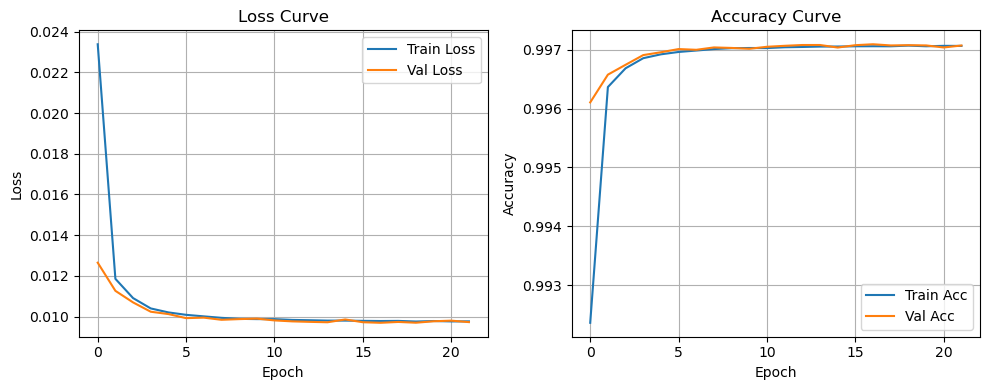

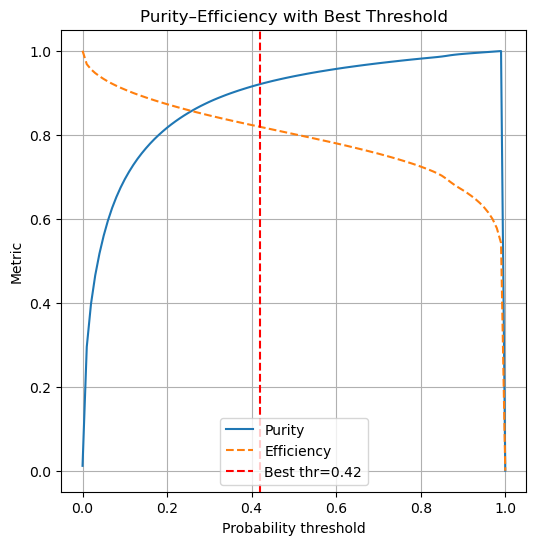

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# === CONFIG ===
# ============================================================
CACHE_PATH = "cached_data/TimeSeries_seq_3000_batch0.npz"

CHECKPOINT_DIR = "checkpoints_snn_seq_3000_batch0_binary_v9"
RESULT_PATH = "results/snn_seq_3000_batch0_binary_cluster_v9.npz"
OUT_FIG_BEST = "results/purity_efficiency_best_v9.png"
OUT_FIG_CURVE = "results/training_curve_v9.png"

BATCH_SIZE = 32
NUM_EPOCHS = 200
PATIENCE = 5          # tightened patience
NUM_TIMESTEPS = 20
NUM_CLASSES = 2

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# ============================================================
# === Load dataset ===
# ============================================================
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes before binarization:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Convert labels to binary
y_train = (y_train > 0).astype(np.int64)
y_test  = (y_test  > 0).astype(np.int64)

print("Label distribution (train):", np.bincount(y_train.reshape(-1)))
print("Label distribution (test):", np.bincount(y_test.reshape(-1)))

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# === Model (Conv→LIF→FC, expanded: 128 → 256 + final LIF) ===
# ============================================================
class ConvSNN_Big(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv1d(input_dim, 128, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.fc1   = nn.Linear(128, 128)

        # Block 2
        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.fc2   = nn.Linear(256, 256)

        # 🔥 Missing activation before output
        self.lif3  = snn.Leaky(beta=beta)

        # Final classifier
        self.fc_out = nn.Linear(256, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3 = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
        )
        spk_out = []

        for _ in range(num_steps):
            # Block 1
            cur1 = self.conv1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = spk1.permute(0, 2, 1)
            spk1 = self.fc1(spk1)

            # Block 2
            spk1 = spk1.permute(0, 2, 1)
            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = spk2.permute(0, 2, 1)
            spk2 = self.fc2(spk2)

            # 🔥 Added Leaky between fc2 and output
            spk2 = spk2.permute(0, 2, 1)
            spk3, mem3 = self.lif3(spk2, mem3)
            spk3 = spk3.permute(0, 2, 1)

            out = self.fc_out(spk3)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)


# ============================================================
# === Training setup + Resume from checkpoint ===
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ConvSNN_Big(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_loss, early_counter = float("inf"), 0
train_curve, val_curve = [], []
train_acc_curve, val_acc_curve = [], []

start_epoch = 1
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pt")
if os.path.exists(last_ckpt):
    print(f"🔄 Resuming training from {last_ckpt}")
    checkpoint = torch.load(last_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
    start_epoch = checkpoint["epoch"]
    train_curve = checkpoint.get("train_curve", [])
    val_curve = checkpoint.get("val_curve", [])
    train_acc_curve = checkpoint.get("train_acc_curve", [])
    val_acc_curve = checkpoint.get("val_acc_curve", [])

# ============================================================
# === Training loop ===
# ============================================================
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch} Training", mininterval=1.0):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)

        loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

        preds = out.argmax(dim=-1)
        correct += (preds == yb).sum().item()
        total += yb.numel()

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # Validation
    val_loss, correct, total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
            val_loss += loss.item() * xb.size(0)

            preds = out.argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total
    print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    # Save curves
    train_curve.append(train_loss)
    val_curve.append(val_loss)
    train_acc_curve.append(train_acc)
    val_acc_curve.append(val_acc)

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        print(f"⚠️ No improvement ({early_counter}/{PATIENCE})")
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break

    # Save last checkpoint
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "train_acc_curve": train_acc_curve,
        "val_acc_curve": val_acc_curve,
    }, last_ckpt)

print("\n🔎 Training complete. Best model saved in", CHECKPOINT_DIR)

# ============================================================
# === Training curve plot ===
# ============================================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_curve, label="Train Loss")
plt.plot(val_curve, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_curve, label="Train Acc")
plt.plot(val_acc_curve, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(OUT_FIG_CURVE)
print(f"📈 Saved training curves to {OUT_FIG_CURVE}")

# ============================================================
# === Final Evaluation (with best model) ===
# ============================================================
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=device))
model.eval()
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        labels = yb.cpu().numpy()
        y_true_all.append(labels)
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

np.savez(RESULT_PATH, probs=y_pred_all, y_true=y_true_all)
print(f"✅ Saved results to {RESULT_PATH}")

# ============================================================
# === Threshold tuning ===
# ============================================================
def tune_best_threshold(y_true, y_probs, thresholds=None, ntest=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 101)
    if ntest is not None:
        y_true = y_true[:ntest]
        y_probs = y_probs[:ntest]

    yt = y_true.reshape(-1).astype(np.int8)
    pp = y_probs[:, :, 1].reshape(-1).astype(np.float32)

    best_thr, best_score = None, -1
    best_p, best_e = 0, 0
    purity, efficiency = [], []

    for thr in thresholds:
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))

        p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        e = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        purity.append(p)
        efficiency.append(e)

        score = 2 * p * e / (p + e) if (p + e) > 0 else 0.0
        if score > best_score:
            best_score = score
            best_thr, best_p, best_e = thr, p, e

    return thresholds, np.array(purity), np.array(efficiency), best_thr, best_p, best_e, best_score

tsteps, pur, eff, best_thr, best_p, best_e, best_score = tune_best_threshold(y_true_all, y_pred_all)

plt.figure(figsize=(6,6))
plt.plot(tsteps, pur, label="Purity")
plt.plot(tsteps, eff, "--", label="Efficiency")
plt.axvline(best_thr, color="r", ls="--", label=f"Best thr={best_thr:.2f}")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Purity–Efficiency with Best Threshold")
plt.grid(True); plt.legend()
plt.savefig(OUT_FIG_BEST)

print(f"Best threshold = {best_thr:.3f}")
print(f"Purity = {best_p*100:.2f}%")
print(f"Efficiency = {best_e*100:.2f}%")
print(f"Balanced score (F1) = {best_score:.3f}")
print(f"✅ Saved plot to {OUT_FIG_BEST}")


Loading dataset...
✅ Shapes before binarization: (100000, 3000, 1) (100000, 3000) (100000, 3000, 1) (100000, 3000)
Label distribution (train): [296511283   3488717]
Label distribution (test): [296518112   3481888]
Using device: cuda


/tmp/ipykernel_440/610456344.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(last_ckpt, map_location=device)


🔄 Resuming training from checkpoints_snn_seq_3000_batch0_binary_v10/last.pt

=== Epoch 9/10 ===


Epoch 9 Training: 100%|██████████| 3125/3125 [21:30<00:00,  2.42it/s]


Train Loss 0.0079 | Train Acc 0.9976 | Val Loss 0.0079 | Val Acc 0.9976
✅ New best model saved

=== Epoch 10/10 ===


...

/tmp/ipykernel_440/610456344.py:246: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=dev

📈 Saved training curves to results/training_curve_v10.png


Evaluating: 100%|██████████| 3125/3125 [09:34<00:00,  5.44it/s]


✅ Saved results to results/snn_seq_3000_batch0_binary_cluster_v10.npz


ValueError: Format '10png' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

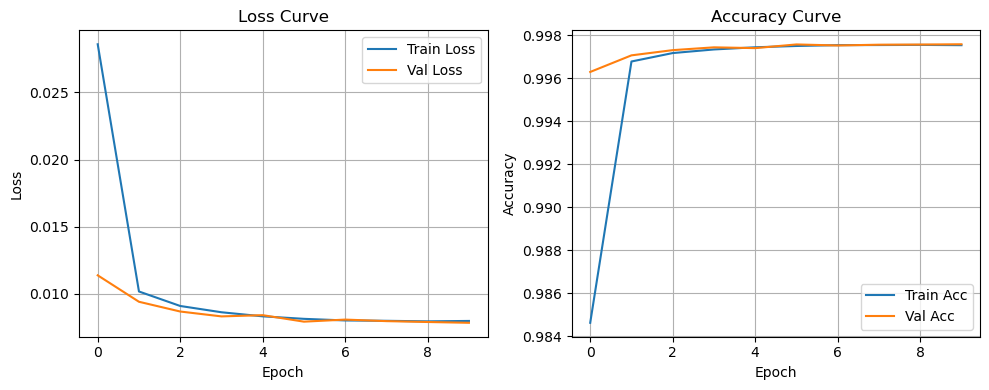

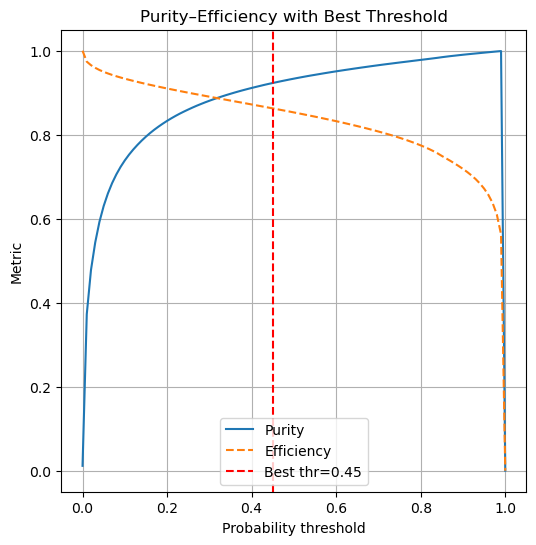

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from tqdm import tqdm

# ============================================================
# === CONFIG ===
# ============================================================
CACHE_PATH = "cached_data/TimeSeries_seq_3000_batch0.npz"

CHECKPOINT_DIR = "checkpoints_snn_seq_3000_batch0_binary_v10"
RESULT_PATH = "results/snn_seq_3000_batch0_binary_cluster_v10.npz"
OUT_FIG_BEST = "results/purity_efficiency_best_v10.10png"
OUT_FIG_CURVE = "results/training_curve_v10.png"

BATCH_SIZE = 32
NUM_EPOCHS = 10       # quick tuning
PATIENCE = 3          # short patience
NUM_TIMESTEPS = 20
NUM_CLASSES = 2

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs("results", exist_ok=True)

# ============================================================
# === Load dataset ===
# ============================================================
print("Loading dataset...")
data = np.load(CACHE_PATH)
X_train, y_train = data["X_train"], data["y_train"]
X_test, y_test   = data["X_test"], data["y_test"]

print("✅ Shapes before binarization:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

# Convert labels to binary
y_train = (y_train > 0).astype(np.int64)
y_test  = (y_test  > 0).astype(np.int64)

print("Label distribution (train):", np.bincount(y_train.reshape(-1)))
print("Label distribution (test):", np.bincount(y_test.reshape(-1)))

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test  = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)

# Torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=BATCH_SIZE, shuffle=False)

# ============================================================
# === Model (Deeper Conv→LIF stack: 4 Conv layers, 32→64→128→128) ===
# ============================================================
class ConvSNN_Deep(nn.Module):
    def __init__(self, input_dim=1, beta=0.5, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 32, kernel_size=5, padding=2)
        self.lif1  = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.lif2  = snn.Leaky(beta=beta)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.lif3  = snn.Leaky(beta=beta)
        self.conv4 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.lif4  = snn.Leaky(beta=beta)

        self.fc1   = nn.Linear(128, 128)
        self.lif_fc = snn.Leaky(beta=beta)
        self.fc_out = nn.Linear(128, num_classes)

    def forward(self, x, num_steps=NUM_TIMESTEPS):
        B, T, _ = x.shape
        x = x.permute(0, 2, 1)

        mem1, mem2, mem3, mem4, mem_fc = (
            self.lif1.init_leaky(),
            self.lif2.init_leaky(),
            self.lif3.init_leaky(),
            self.lif4.init_leaky(),
            self.lif_fc.init_leaky(),
        )
        spk_out = []

        for _ in range(num_steps):
            cur1 = self.conv1(x); spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.conv2(spk1); spk2, mem2 = self.lif2(cur2, mem2)
            cur3 = self.conv3(spk2); spk3, mem3 = self.lif3(cur3, mem3)
            cur4 = self.conv4(spk3); spk4, mem4 = self.lif4(cur4, mem4)

            spk4 = spk4.permute(0, 2, 1)
            fc = self.fc1(spk4)
            spk_fc, mem_fc = self.lif_fc(fc, mem_fc)
            out = self.fc_out(spk_fc)
            spk_out.append(out)

        return torch.stack(spk_out, dim=2).mean(dim=2)


# ============================================================
# === Training setup + Resume from checkpoint ===
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = ConvSNN_Deep(num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_loss, early_counter = float("inf"), 0
train_curve, val_curve = [], []
train_acc_curve, val_acc_curve = [], []

start_epoch = 1
last_ckpt = os.path.join(CHECKPOINT_DIR, "last.pt")
if os.path.exists(last_ckpt):
    print(f"🔄 Resuming training from {last_ckpt}")
    checkpoint = torch.load(last_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    best_loss = checkpoint["best_loss"]
    early_counter = checkpoint["early_counter"]
    start_epoch = checkpoint["epoch"]
    train_curve = checkpoint.get("train_curve", [])
    val_curve = checkpoint.get("val_curve", [])
    train_acc_curve = checkpoint.get("train_acc_curve", [])
    val_acc_curve = checkpoint.get("val_acc_curve", [])

# ============================================================
# === Training loop ===
# ============================================================
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n=== Epoch {epoch}/{NUM_EPOCHS} ===")
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch} Training", mininterval=1.0):
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)

        loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

        preds = out.argmax(dim=-1)
        correct += (preds == yb).sum().item()
        total += yb.numel()

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    # Validation
    val_loss, correct, total = 0, 0, 0
    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out.reshape(-1, NUM_CLASSES), yb.reshape(-1))
            val_loss += loss.item() * xb.size(0)

            preds = out.argmax(dim=-1)
            correct += (preds == yb).sum().item()
            total += yb.numel()

    val_loss /= len(test_loader.dataset)
    val_acc = correct / total
    print(f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
          f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

    # Save curves
    train_curve.append(train_loss)
    val_curve.append(val_loss)
    train_acc_curve.append(train_acc)
    val_acc_curve.append(val_acc)

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        early_counter = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ New best model saved")
    else:
        early_counter += 1
        print(f"⚠️ No improvement ({early_counter}/{PATIENCE})")
        if early_counter >= PATIENCE:
            print("🛑 Early stopping triggered.")
            break

    # Save last checkpoint
    torch.save({
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "best_loss": best_loss,
        "early_counter": early_counter,
        "train_curve": train_curve,
        "val_curve": val_curve,
        "train_acc_curve": train_acc_curve,
        "val_acc_curve": val_acc_curve,
    }, last_ckpt)

print("\n🔎 Training complete. Best model saved in", CHECKPOINT_DIR)

# ============================================================
# === Training curve plot ===
# ============================================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_curve, label="Train Loss")
plt.plot(val_curve, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.grid(True)
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_acc_curve, label="Train Acc")
plt.plot(val_acc_curve, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig(OUT_FIG_CURVE)
print(f"📈 Saved training curves to {OUT_FIG_CURVE}")

# ============================================================
# === Final Evaluation (with best model) ===
# ============================================================
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt"), map_location=device))
model.eval()
y_true_all, y_pred_all = [], []

with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="Evaluating"):
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=-1).cpu().numpy()
        labels = yb.cpu().numpy()
        y_true_all.append(labels)
        y_pred_all.append(probs)

y_true_all = np.concatenate(y_true_all, axis=0)
y_pred_all = np.concatenate(y_pred_all, axis=0)

np.savez(RESULT_PATH, probs=y_pred_all, y_true=y_true_all)
print(f"✅ Saved results to {RESULT_PATH}")

# ============================================================
# === Threshold tuning ===
# ============================================================
def tune_best_threshold(y_true, y_probs, thresholds=None, ntest=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 101)
    if ntest is not None:
        y_true = y_true[:ntest]
        y_probs = y_probs[:ntest]

    yt = y_true.reshape(-1).astype(np.int8)
    pp = y_probs[:, :, 1].reshape(-1).astype(np.float32)

    best_thr, best_score = None, -1
    best_p, best_e = 0, 0
    purity, efficiency = [], []

    for thr in thresholds:
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))

        p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        e = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        purity.append(p)
        efficiency.append(e)

        score = 2 * p * e / (p + e) if (p + e) > 0 else 0.0
        if score > best_score:
            best_score = score
            best_thr, best_p, best_e = thr, p, e

    return thresholds, np.array(purity), np.array(efficiency), best_thr, best_p, best_e, best_score

tsteps, pur, eff, best_thr, best_p, best_e, best_score = tune_best_threshold(y_true_all, y_pred_all)

plt.figure(figsize=(6,6))
plt.plot(tsteps, pur, label="Purity")
plt.plot(tsteps, eff, "--", label="Efficiency")
plt.axvline(best_thr, color="r", ls="--", label=f"Best thr={best_thr:.2f}")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Purity–Efficiency with Best Threshold")
plt.grid(True); plt.legend()
plt.savefig(OUT_FIG_BEST)

print(f"Best threshold = {best_thr:.3f}")
print(f"Purity = {best_p*100:.2f}%")
print(f"Efficiency = {best_e*100:.2f}%")
print(f"Balanced score (F1) = {best_score:.3f}")
print(f"✅ Saved plot to {OUT_FIG_BEST}")


Best threshold = 0.450
Purity = 92.32%
Efficiency = 86.27%
Balanced score (F1) = 0.892
✅ Saved plot to results/purity_efficiency_best_v10.png


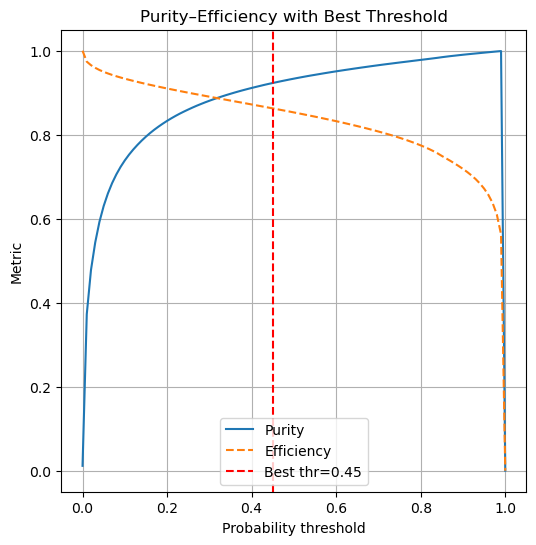

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Paths (make sure these match your version)
RESULT_PATH = "results/snn_seq_3000_batch0_binary_cluster_v10.npz"
OUT_FIG_BEST = "results/purity_efficiency_best_v10.png"

# --- reload saved probabilities ---
data = np.load(RESULT_PATH)
y_true_all, y_pred_all = data["y_true"], data["probs"]

# --- use your existing helper function ---
def tune_best_threshold(y_true, y_probs, thresholds=None, ntest=None):
    if thresholds is None:
        thresholds = np.linspace(0.0, 1.0, 101)
    if ntest is not None:
        y_true = y_true[:ntest]
        y_probs = y_probs[:ntest]

    yt = y_true.reshape(-1).astype(np.int8)
    pp = y_probs[:, :, 1].reshape(-1).astype(np.float32)

    best_thr, best_score = None, -1
    best_p, best_e = 0, 0
    purity, efficiency = [], []

    for thr in thresholds:
        pred = pp >= thr
        TP = np.sum(pred & (yt == 1))
        FP = np.sum(pred & (yt == 0))
        FN = np.sum((~pred) & (yt == 1))

        p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        e = TP / (TP + FN) if (TP + FN) > 0 else 0.0

        purity.append(p)
        efficiency.append(e)

        score = 2 * p * e / (p + e) if (p + e) > 0 else 0.0
        if score > best_score:
            best_score = score
            best_thr, best_p, best_e = thr, p, e

    return thresholds, np.array(purity), np.array(efficiency), best_thr, best_p, best_e, best_score

# --- compute and plot ---
tsteps, pur, eff, best_thr, best_p, best_e, best_score = tune_best_threshold(y_true_all, y_pred_all)

plt.figure(figsize=(6,6))
plt.plot(tsteps, pur, label="Purity")
plt.plot(tsteps, eff, "--", label="Efficiency")
plt.axvline(best_thr, color="r", ls="--", label=f"Best thr={best_thr:.2f}")
plt.xlabel("Probability threshold")
plt.ylabel("Metric")
plt.title("Purity–Efficiency with Best Threshold")
plt.grid(True)
plt.legend()
plt.savefig(OUT_FIG_BEST)

print(f"Best threshold = {best_thr:.3f}")
print(f"Purity = {best_p*100:.2f}%")
print(f"Efficiency = {best_e*100:.2f}%")
print(f"Balanced score (F1) = {best_score:.3f}")
print(f"✅ Saved plot to {OUT_FIG_BEST}")
